In [1]:
import pandas as pd
df = pd.read_csv("cleaned_employee_data.csv")

In [2]:
df['promoted'].value_counts()
df['promoted'].value_counts(normalize=True)

promoted
0    0.9
1    0.1
Name: proportion, dtype: float64

In [3]:
df.describe()

,age,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,peer_feedback_score,...,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted,performance_growth,efficiency,promotion_gap
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,40.558140,5.489030,2.750630,2.749650,11.014010,70.097429,68.166798,65.102153,3.302642,3.493660,...,5658.466284,0.928158,1.993690,69.916845,67.907766,50.011404,0.100000,1.930631,0.208034,2.749650
std,10.951788,3.481758,2.746004,2.733337,4.910633,14.717013,13.867294,11.773939,0.765938,0.816753,...,1264.375203,0.046578,1.415977,14.719348,15.665689,19.714147,0.300002,5.838221,0.086557,2.733337
min,22.000000,0.000000,0.000000,0.000000,3.000000,40.000000,40.000000,40.000000,1.000000,1.000000,...,788.905587,0.727631,0.000000,20.000000,20.000000,0.000000,0.000000,-22.260709,0.011652,0.000000
25%,31.000000,3.000000,1.000000,1.000000,7.000000,59.499890,58.357646,56.954026,2.769433,2.926620,...,4809.857296,0.896236,1.000000,59.887391,57.184464,36.534728,0.000000,-1.937227,0.145747,1.000000
50%,41.000000,5.000000,2.000000,2.000000,11.000000,69.980013,68.033605,65.018847,3.302663,3.506368,...,5661.913481,0.930238,2.000000,70.025028,68.032234,50.043370,0.000000,1.827363,0.200836,2.000000
75%,50.000000,7.000000,4.000000,4.000000,15.000000,80.596442,77.791895,73.121749,3.837462,4.085017,...,6508.183945,0.963801,3.000000,80.159887,78.895916,63.409152,0.000000,5.831633,0.262309,4.000000
max,59.000000,30.000000,28.000000,29.000000,19.000000,100.000000,100.000000,100.000000,5.000000,5.000000,...,10846.763857,1.000000,12.000000,100.000000,100.000000,100.000000,1.000000,25.159124,0.700056,29.000000


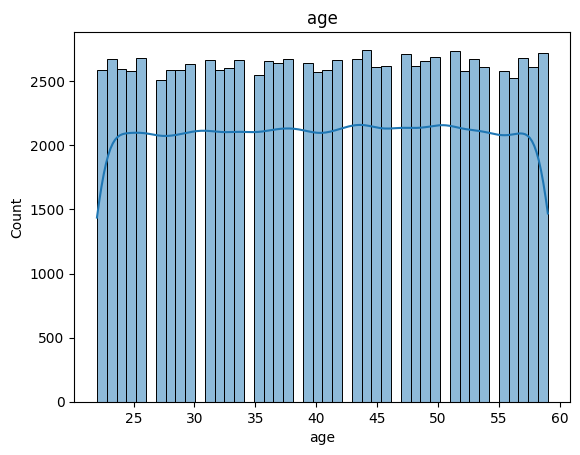

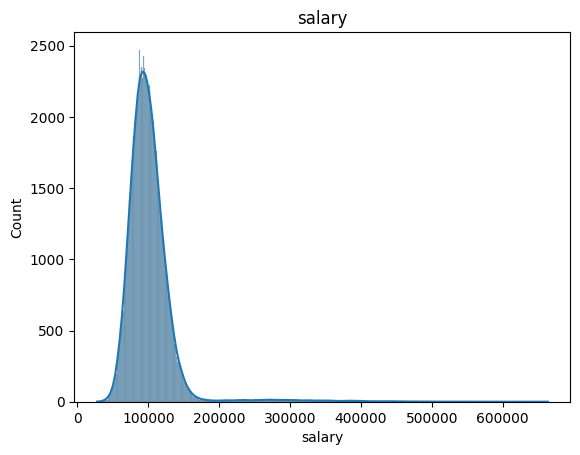

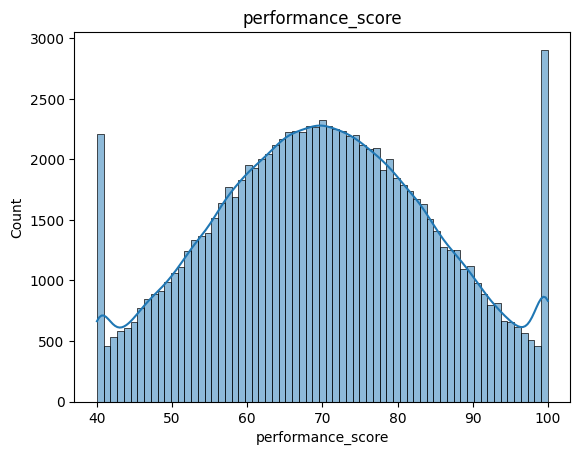

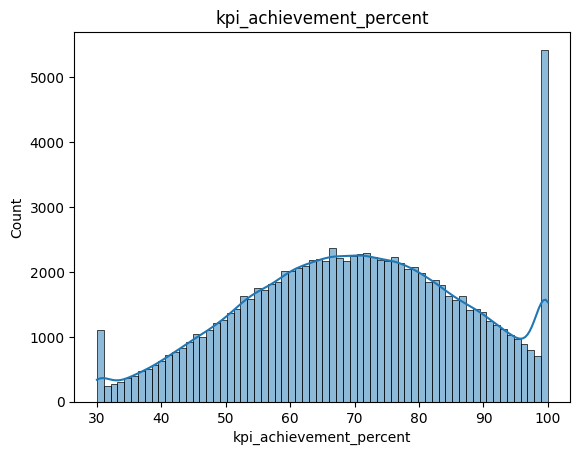

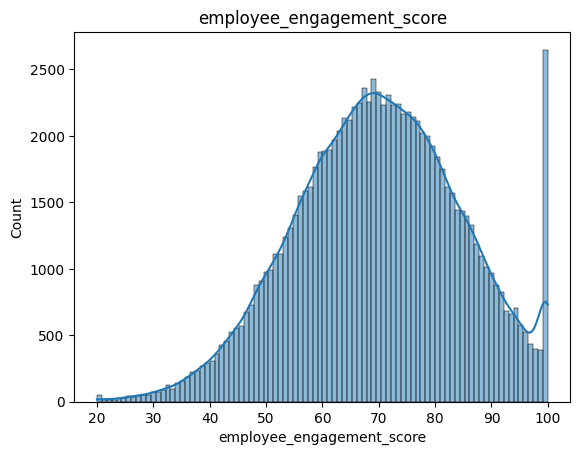

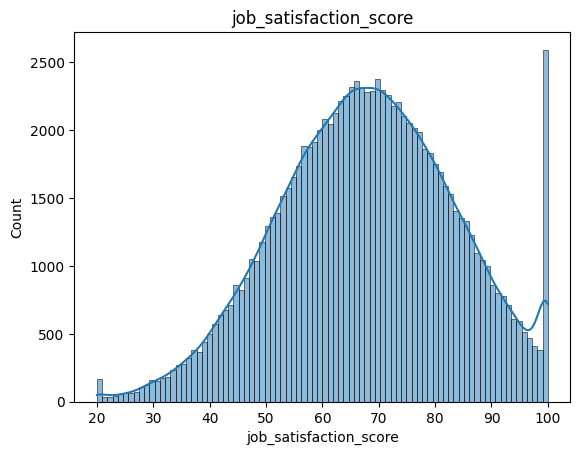

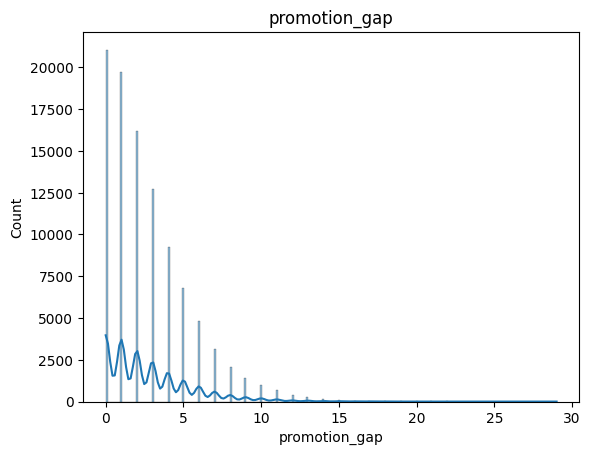

In [4]:
important_features = [
    'age', 'salary', 'performance_score',
    'kpi_achievement_percent',
    'employee_engagement_score',
    'job_satisfaction_score',
    'promotion_gap'
]

import seaborn as sns
import matplotlib.pyplot as plt

for col in important_features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

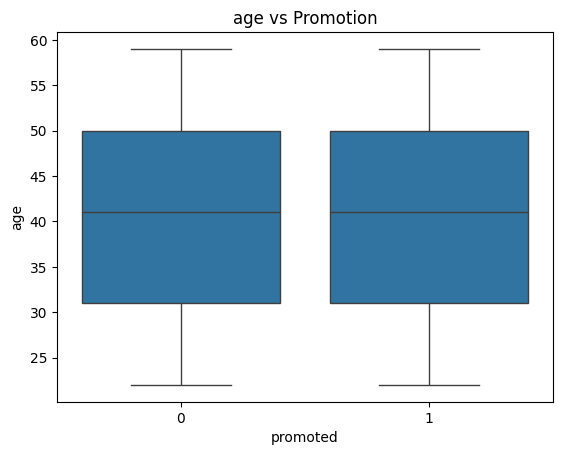

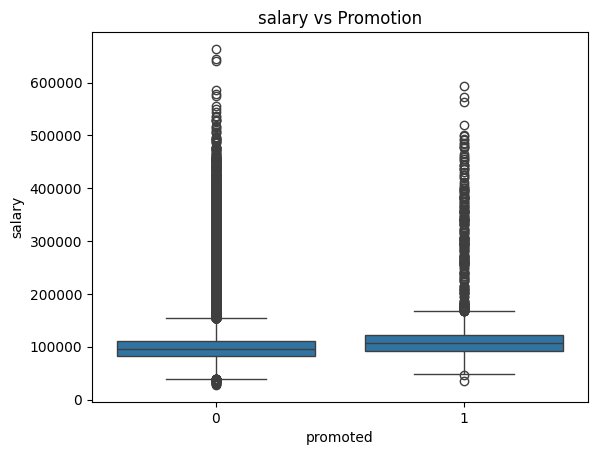

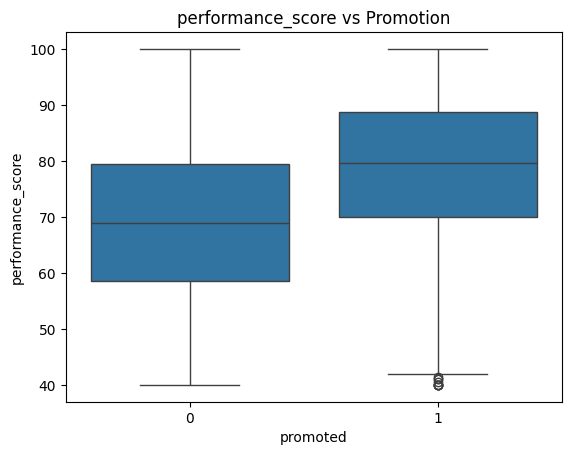

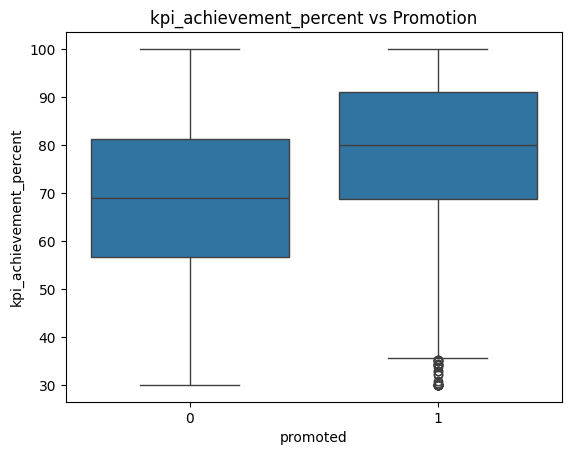

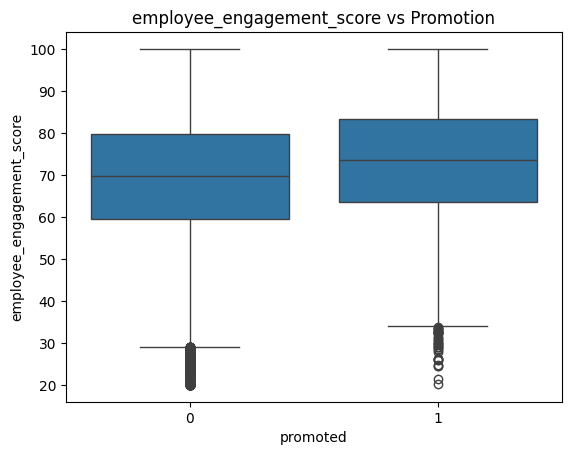

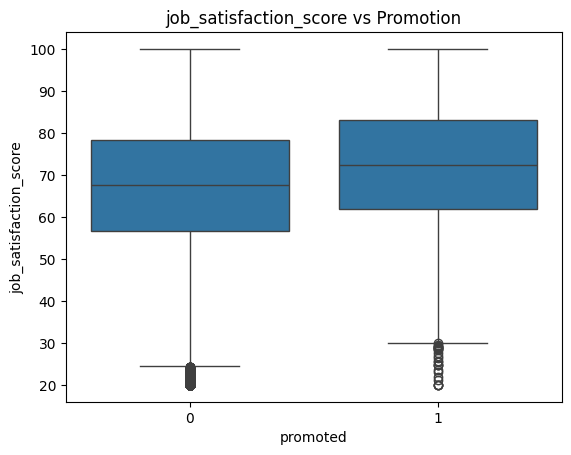

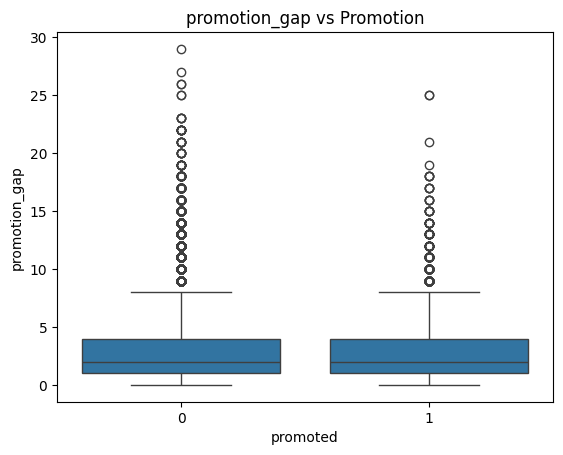

In [5]:
for col in important_features:
    plt.figure()
    sns.boxplot(x='promoted', y=col, data=df)
    plt.title(f"{col} vs Promotion")
    plt.show()

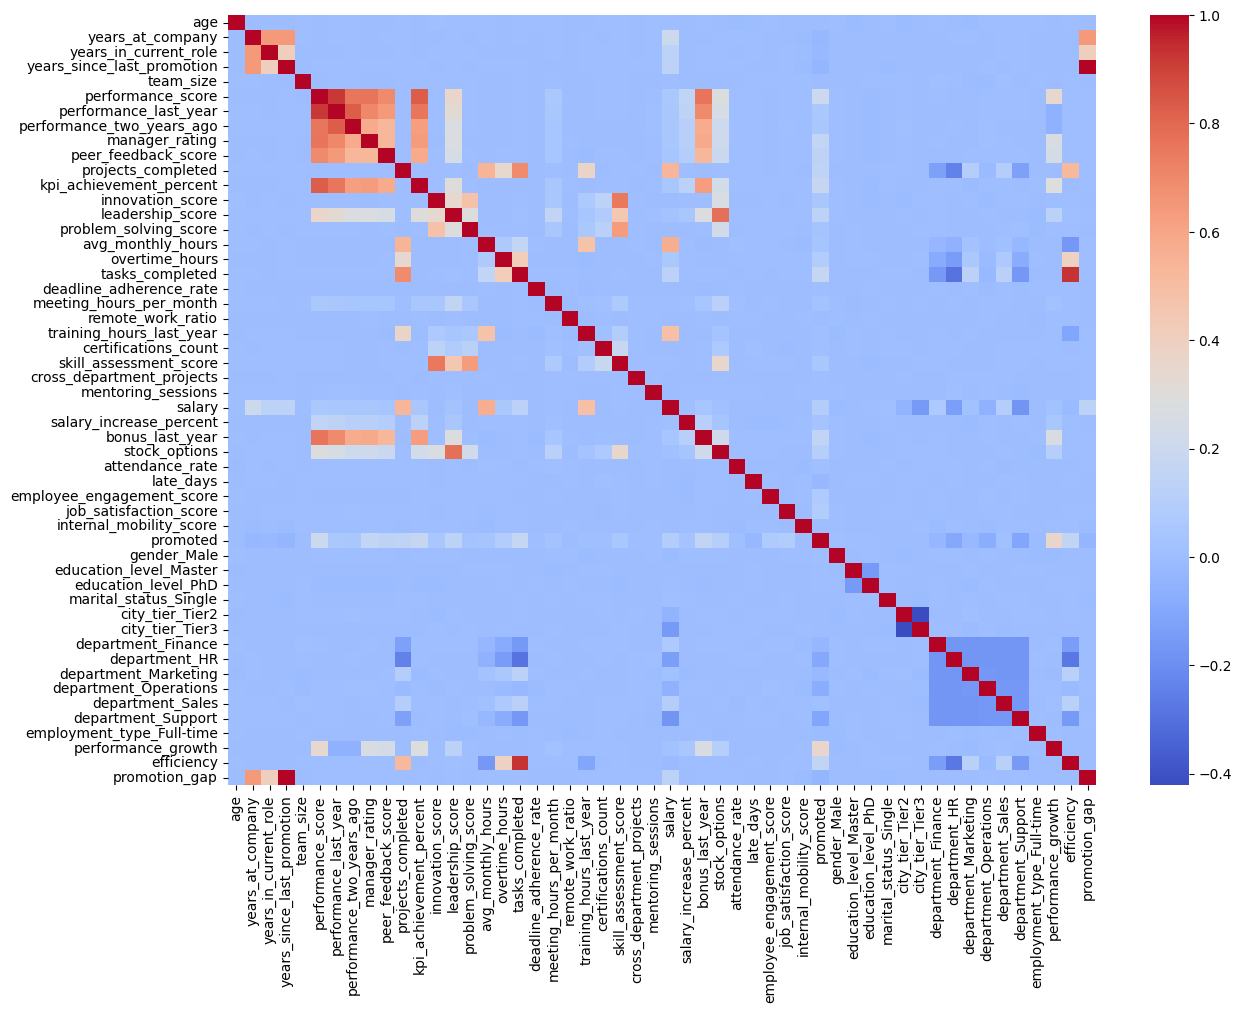

In [7]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

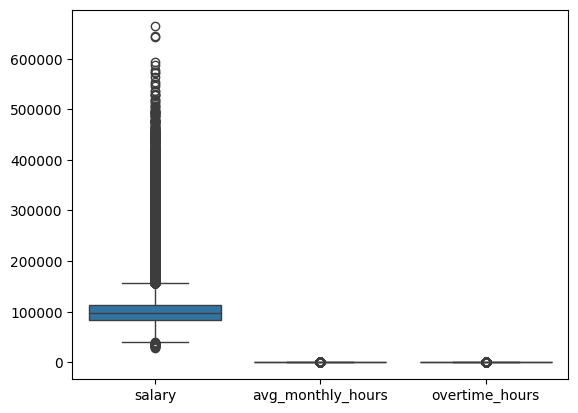

In [8]:
sns.boxplot(data=df[['salary','avg_monthly_hours','overtime_hours']])
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('promoted', axis=1)
y = df['promoted']

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

performance_growth           0.155849
performance_score            0.038528
tasks_completed              0.034104
salary                       0.032827
performance_last_year        0.032596
job_satisfaction_score       0.031745
employee_engagement_score    0.029073
efficiency                   0.029011
kpi_achievement_percent      0.028169
leadership_score             0.026782
dtype: float64

In [10]:
corr = df.corr().abs()
high_corr = corr[corr > 0.8]

<Axes: >

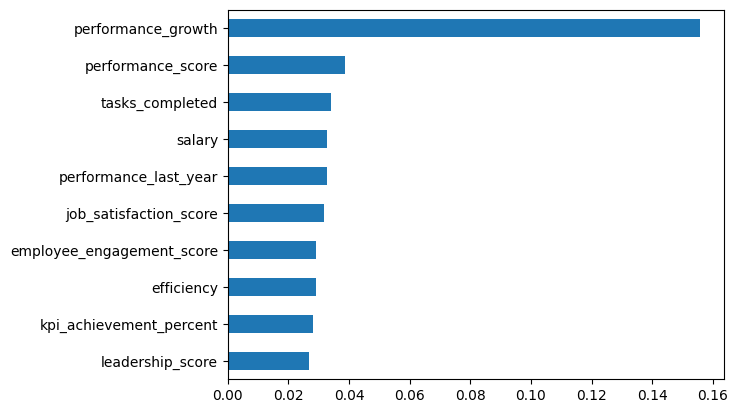

In [11]:
importances.sort_values().tail(10).plot(kind='barh')